In [1]:
import numpy as np

#### Using the Spherical Law of Cosines, convert the inclination w.r.t. the ecliptic to the inclination e.r.t. the Sun's Equator

The formula to find the inclination to the Sun's equator ($i_{eq}$) is:$$\cos(i_{eq}) = \cos(i_{ec}) \cos(i_{\odot}) + \sin(i_{ec}) \sin(i_{\odot}) \cos(\Omega - \Omega_{\odot})$$

In [2]:

class Asteroid_Table:
    # Define the constants (in degrees)

    # The inclination of the Sun's equator relative to the ecliptic:
    i_sun = 7.25
    # The Longitude of the Ascending Node of the Sun's equator 
    omega_sun = 75.76

    def __init__(self, name, semi_major_axis, eccentricity, inclination_ecliptic, longitude_of_ascending_node):
        self.name = name
        self.a = semi_major_axis
        self.e = eccentricity
        self.i_ec = inclination_ecliptic 
        self.node = longitude_of_ascending_node 

    def get_i_eq(self):
        """
        Calculates the inclination with respect to the Sun's equator.
        Handles the necessary conversions between degrees and radians.
        """
        # Step 1. Convert all degree values to radians for numpy math
        i_ec_rad = np.radians(self.i_ec)
        i_sun_rad = np.radians(self.i_sun)
        node_rad = np.radians(self.node)
        omega_sun_rad = np.radians(self.omega_sun)
        
        # Step 2. Apply The Spherical Law of Cosines
        cos_i_eq = (np.cos(i_ec_rad) * np.cos(i_sun_rad) + 
                    np.sin(i_ec_rad) * np.sin(i_sun_rad) * np.cos(node_rad - omega_sun_rad))
        
        # Step 3. Apply the arccosine and convert back to degrees
        i_eq_rad = np.arccos(cos_i_eq)
        return np.degrees(i_eq_rad)

# Orbital elements populated from Jet Propulsion Laboratory, Solar System Database (https://ssd.jpl.nasa.gov/horizons/app.html#/)
# Osculating Epoch: [Whatever date was on the site], Reference Frame: ECLIPJ2000

# Format: Name, a (au), e, i_ec (degrees), node (degrees)
asteroids = [
    Asteroid_Table("1566 Icarus", 1.078, 0.827, 22.8254, 88.0107),
    Asteroid_Table("1998 TU3",    0.787, 0.484, 5.4132,  127.0503),
    Asteroid_Table("1999 KW4",    0.642, 0.688, 38.8839, 244.9084),
    Asteroid_Table("1999 MN",     0.674, 0.665, 2.0163,  71.0427),
    Asteroid_Table("2000 BD19",   0.876, 0.895, 25.6882, 333.6548),
    Asteroid_Table("2000 EE14",   0.662, 0.533, 26.5186, 283.0031),
    Asteroid_Table("2001 YE4",    0.677, 0.541, 4.8217,  108.9712),
    Asteroid_Table("2004 KH17",   0.712, 0.499, 22.1009, 22.1818),
    Asteroid_Table("2006 CJ",     0.676, 0.755, 10.2526, 57.0560)
]

# Then print the formatted table header
print(f"{'Target':<15} | {'a (au)':<10} | {'e':<10} | {'i_ec (deg)':<20} | {'i_eq (deg)':<20}")
print("-" * 85)

# Calculate and print the unrounded values for each asteroid 
for ast in asteroids:
    i_eq_unrounded = ast.get_i_eq()
    print(f"{ast.name:<15} | {ast.a:<10} | {ast.e:<10} | {ast.i_ec:<20} | {i_eq_unrounded:<20}")

Target          | a (au)     | e          | i_ec (deg)           | i_eq (deg)          
-------------------------------------------------------------------------------------
1566 Icarus     | 1.078      | 0.827      | 22.8254              | 15.811537342448243  
1998 TU3        | 0.787      | 0.484      | 5.4132               | 5.716948122024405   
1999 KW4        | 0.642      | 0.688      | 38.8839              | 46.02121295369019   
1999 MN         | 0.674      | 0.665      | 2.0163               | 5.243138767511647   
2000 BD19       | 0.876      | 0.895      | 25.6882              | 28.055839492951286  
2000 EE14       | 0.662      | 0.533      | 26.5186              | 33.11878914141162   
2001 YE4        | 0.677      | 0.541      | 4.8217               | 4.156861455781174   
2004 KH17       | 0.712      | 0.499      | 22.1009              | 18.68292965448669   
2006 CJ         | 0.676      | 0.755      | 10.2526              | 4.099908527963058   


In [3]:
# The time when the initial conditions were extracted:



### Create a CSV File with the initial conditions (precise measurements) for the 9 asteroids (by pulling them from the SSD JPL NASA website)

In [4]:
import requests
import pandas as pd


def fetch_asteroid_full_precision(name):
    url = "https://ssd-api.jpl.nasa.gov/sbdb.api"
    params = {"sstr": name, "full-prec": "true"}

    data = requests.get(url, params=params).json()
    elems = data["orbit"]["elements"]

    def get(label):
        for el in elems:
            if el.get("label") == label:
                return el.get("value")
        return None

    return {
        "name": name,
        "a": get("a"),
        "e": get("e"),
        "i": get("i"),
        "node": get("node"),
        "peri": get("peri"),
        "M": get("M"),
        "n": get("n"),
        #"epoch": get("epoch")
    }


asteroid_names = [
    "1566 Icarus",
    "1998 TU3",
    "1999 KW4",
    "1999 MN",
    "2000 BD19",
    "2000 EE14",
    "2001 YE4",
    "2004 KH17",
    "2006 CJ"
]

rows = [fetch_asteroid_full_precision(n) for n in asteroid_names]

df = pd.DataFrame(rows)

df.to_csv("asteroids_full_precision.csv", index=False)

print("CSV written: asteroids_full_precision.csv")

CSV written: asteroids_full_precision.csv


In [3]:
import numpy as np
import pandas as pd


class Asteroid_Table:
    # Define the constants (in degrees)

    # The inclination of the Sun's equator relative to the ecliptic:
    i_sun = 7.25
    # The Longitude of the Ascending Node of the Sun's equator 
    omega_sun = 75.76

    def __init__(self, name, a, e, i_ec, node, peri, M, n):
        self.name = name

        # Store the values as floats for computation
        self.a = float(a)
        self.e = float(e)
        self.i_ec = float(i_ec)
        self.node = float(node)
        self.peri = float(peri)
        self.M = float(M)
        self.n = float(n)
        #self.epoch = epoch  

    def get_i_eq(self):
        """
        A function to calculate the inclination with respect to the Sun's equator.
        The function also tackles the necessary conversions between degrees and radians.
        """

        # Step 1. Convert all degree values to radians for numpy math
        i_ec_rad = np.radians(self.i_ec)
        i_sun_rad = np.radians(self.i_sun)
        node_rad = np.radians(self.node)
        omega_sun_rad = np.radians(self.omega_sun)

        # Step 2. Apply The Spherical Law of Cosines
        cos_i_eq = (
            np.cos(i_ec_rad) * np.cos(i_sun_rad) + np.sin(i_ec_rad) * np.sin(i_sun_rad)
            * np.cos(node_rad - omega_sun_rad)
        )

        # Step 3. Apply the arccosine and convert back to degrees
        i_eq_rad = np.arccos(cos_i_eq)
        return np.degrees(i_eq_rad)


# Now pull out the asteroids' values from the CSV file
def load_asteroids(csv_file):
    df = pd.read_csv(csv_file)

    return [
        Asteroid_Table(
            row["name"],
            row["a"],
            row["e"],
            row["i"],
            row["node"],
            row["peri"],
            row["M"],
            row["n"],
            #row["epoch"]
        )
        for _, row in df.iterrows()
    ]


asteroids = load_asteroids("asteroids_full_precision.csv")


print(
    f"{'Target':<15} | {'a (AU)':<8} | {'e':<8} | {'i (deg)':<8} | {'node (deg)':<10} | "
    f"{'peri (deg)':<10} | {'M (deg)':<10} | {'i_eq (deg)':<8} | {'n (deg/day)':<8}"
)

print("-" * 120)

for ast in asteroids:
    i_eq = ast.get_i_eq()

    print(
        f"{ast.name:<15} | "
        f"{ast.a:<8.5f} | "
        f"{ast.e:<8.5f} | "
        f"{ast.i_ec:<8.5f} | "
        f"{ast.node:<10.5f} | "
        f"{ast.peri:<10.5f} | "
        f"{ast.M:<10.5f} | "
        #f"{ast.epoch:<20} | "
        f"{i_eq:<10f} |"
        f"{ast.n:<10.5f} | "       
    )

Target          | a (AU)   | e        | i (deg)  | node (deg) | peri (deg) | M (deg)    | i_eq (deg) | n (deg/day)
------------------------------------------------------------------------------------------------------------------------
1566 Icarus     | 1.07799  | 0.82702  | 22.80164 | 87.94856   | 31.44439   | 329.18266  | 15.785529  |0.88060    | 
1998 TU3        | 0.78757  | 0.48370  | 5.41528  | 101.87731  | 84.98796   | 356.82196  | 3.369478   |1.41017    | 
1999 KW4        | 0.64239  | 0.68838  | 38.87862 | 244.89559  | 192.65394  | 5.45674    | 46.015670  |1.91429    | 
1999 MN         | 0.67407  | 0.66532  | 2.03184  | 81.38441   | 9.20970    | 103.70942  | 5.231713   |1.78091    | 
2000 BD19       | 0.87648  | 0.89497  | 25.75726 | 333.65517  | 324.38756  | 213.42344  | 28.122440  |1.20114    | 
2000 EE14       | 0.66183  | 0.53307  | 26.45905 | 155.74476  | 197.85461  | 94.64671   | 26.119959  |1.83055    | 
2001 YE4        | 0.67685  | 0.54043  | 4.85329  | 305.31620  | 319.

## How to calculate the perihelion precession

In [ ]:
def calc_perihelion_shift(a_au, e, i_deg, beta=1, gamma=1, J2_sun = 2.2e-7):
    """
    Calculates dw in arcseconds per century ("/cy).
    Assume gamma=1 and beta=1 and the solar quadrupole moment is J2_sun=2.2*10**(-7).
    """
    # Physical Constants (SI Units)
    G = 6.6743e-11        # m^3 / (kg s^2)
    M_sun = 1.98847e30    # kg
    c = 299792458.0       # m/s
    R_sun = 6.957e8       # m
    AU = 1.495978707e11   # meters
    
    # Unit conversions
    # Otherwise the equation doesn't work :)
    a_m = a_au * AU
    i_rad = np.radians(i_deg)
    
    # 1. GR Term
    gr_factor = (2 - beta + 2 * gamma) / 3.0
    term1 = (6 * np.pi * G * M_sun) / (a_m * (1 - e**2) * c**2) * gr_factor
    
    # 2. J2 Solar Oblateness Term
    term2 = (3 * np.pi * R_sun**2 * J2_sun) / (a_m**2 * (1 - e**2)**2) * (1 - 1.5 * np.sin(i_rad)**2)
    
    # Total shift per orbit (in radians)
    dw_orbit_rad = term1 + term2
    
    # Convert per orbit -> per year -> per century
    period_years = a_au**1.5
    dw_year_rad = dw_orbit_rad / period_years
    dw_century_rad = dw_year_rad * 100
    
    # Convert radians -> arcseconds
    dw_century_arcsec = np.degrees(dw_century_rad) * 3600
    return dw_century_arcsec

In [ ]:
# Calculating the errors:

def calc_dw_uncertainty(a, e, i_deg, sa, se, si, sbeta=8.0e-5, sgamma=2.3e-5, sJ2=1.0e-8):
    """Propagates errors using central finite difference numerical derivatives"""
    h = 1e-5
    
    # Partial derivatives with respect to orbital parameters
    ddw_da = (calc_perihelion_shift(a+h, e, i_deg) - calc_perihelion_shift(a-h, e, i_deg)) / (2*h)
    ddw_de = (calc_perihelion_shift(a, e+h, i_deg) - calc_perihelion_shift(a, e-h, i_deg)) / (2*h)
    ddw_di = (calc_perihelion_shift(a, e, i_deg+h) - calc_perihelion_shift(a, e, i_deg-h)) / (2*h)
    
    # Partial derivatives with respect to physical parameters
    ddw_dbeta = (calc_perihelion_shift(a, e, i_deg, beta=1.0+h) - calc_perihelion_shift(a, e, i_deg, beta=1.0-h)) / (2*h)
    ddw_dgamma = (calc_perihelion_shift(a, e, i_deg, gamma=1.0+h) - calc_perihelion_shift(a, e, i_deg, gamma=1.0-h)) / (2*h)
    ddw_dJ2 = (calc_perihelion_shift(a, e, i_deg, J2=2.2e-7+h) - calc_perihelion_shift(a, e, i_deg, J2=2.2e-7-h)) / (2*h)
    
    # Square sum variance propagation
    variance = (ddw_da * sa)**2 + (ddw_de * se)**2 + (ddw_di * si)**2 + \
               (ddw_dbeta * sbeta)**2 + (ddw_dgamma * sgamma)**2 + (ddw_dJ2 * sJ2)**2
    return np.sqrt(variance)

Target          | a (AU)   | e        | i (deg)  | node (deg) | peri (deg) | M (deg)    | i_eq (deg) | dw ("/cy) 
-------------------------------------------------------------------------------------------------------------------
1566 Icarus     | 1.07799  | 0.82702  | 22.80164 | 87.94856   | 31.44439   | 329.18266  | 15.78553   | 10.07023  
1998 TU3        | 0.78757  | 0.48370  | 5.41528  | 101.87731  | 84.98796   | 356.82196  | 3.36948    | 9.10507   
1999 KW4        | 0.64239  | 0.68838  | 38.87862 | 244.89559  | 192.65394  | 5.45674    | 46.01567   | 22.06095  
1999 MN         | 0.67407  | 0.66532  | 2.03184  | 81.38441   | 9.20970    | 103.70942  | 5.23171    | 18.46979  
2000 BD19       | 0.87648  | 0.89497  | 25.75726 | 333.65517  | 324.38756  | 213.42344  | 28.12244   | 26.83787  
2000 EE14       | 0.66183  | 0.53307  | 26.45905 | 155.74476  | 197.85461  | 94.64671   | 26.11996   | 15.05064  
2001 YE4        | 0.67685  | 0.54043  | 4.85329  | 305.31620  | 319.00217  | 187.14413

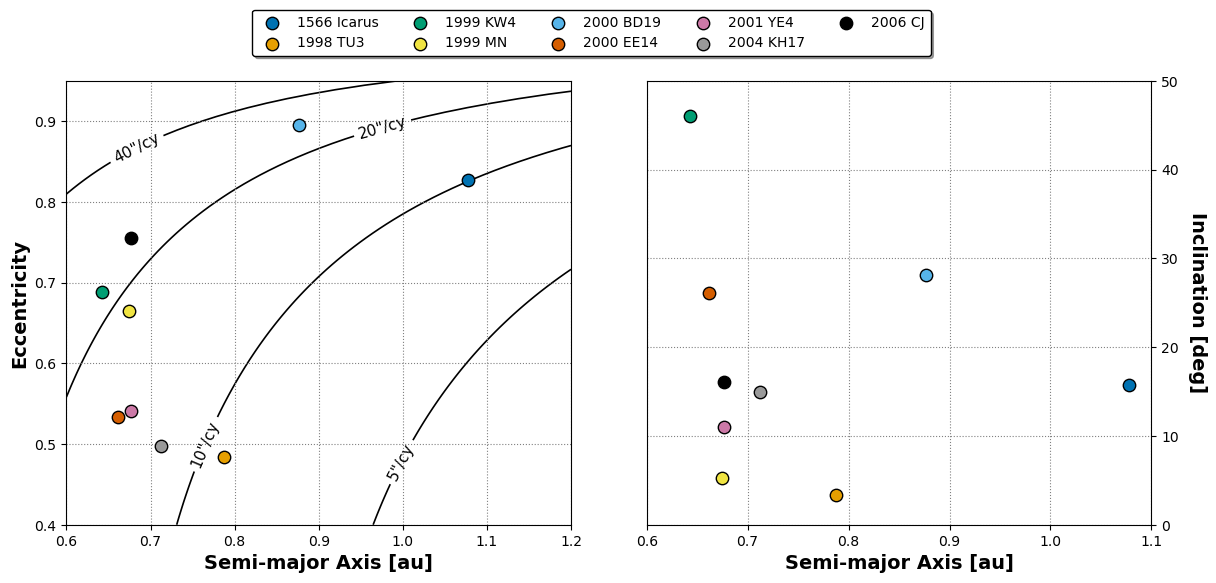

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_asteroids(csv_file):
    df = pd.read_csv(csv_file)
    return [
        Asteroid_Table(
            row["name"], row["a"], row["e"], row["i"],
            row["node"], row["peri"], row["M"], row["n"]
        ) for _, row in df.iterrows()
    ]

# Load data
asteroids = load_asteroids("asteroids_full_precision.csv")

dw_header = 'dw ("/cy)'
print(
    f"{'Target':<15} | {'a (AU)':<8} | {'e':<8} | {'i (deg)':<8} | {'node (deg)':<10} | "
    f"{'peri (deg)':<10} | {'M (deg)':<10} | {'i_eq (deg)':<10} | {dw_header:<10}"
)
print("-" * 115)

# Storing plot data
plot_data = []

# Using your For Loop Structure
for ast in asteroids:
    i_eq = ast.get_i_eq()
    dw = calc_perihelion_shift(ast.a, ast.e, ast.i_ec)
    
    # Append to plot data to draw afterwards
    plot_data.append((ast.name, ast.a, ast.e, ast.i_ec, i_eq, dw))
    
    print(
        f"{ast.name:<15} | "
        f"{ast.a:<8.5f} | "
        f"{ast.e:<8.5f} | "
        f"{ast.i_ec:<8.5f} | "
        f"{ast.node:<10.5f} | "
        f"{ast.peri:<10.5f} | "
        f"{ast.M:<10.5f} | "
        f"{i_eq:<10.5f} | "
        f"{dw:<10.5f}"       
    )

# -------------------------------------------------------------
# Matplotlib Plotting Phase
# -------------------------------------------------------------
colors = ['#0072B2', '#E69F00', '#009E73', '#F0E442', '#56B4E9', '#D55E00', '#CC79A7', '#999999', '#000000']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.15, top=0.85)

for i, p_data in enumerate(plot_data):
    name, a, e, i_ec, i_eq, dw = p_data
    color = colors[i % len(colors)]
    
    # Left plot (a vs e)
    ax1.scatter(a, e, c=color, label=name, edgecolors='black', s=80, zorder=3)
    
    # Right plot (a vs i_eq)
    ax2.scatter(a, i_eq, c=color, edgecolors='black', s=80, zorder=3)

# Contour Lines Grid Setup
a_grid = np.linspace(0.6, 1.2, 100)
e_grid = np.linspace(0.4, 0.95, 100)
A, E = np.meshgrid(a_grid, e_grid)
DW = calc_perihelion_shift(A, E, i_deg=0)

levels = [5, 10, 20, 40]
cs = ax1.contour(A, E, DW, levels=levels, colors='black', linewidths=1.2, zorder=1)
fmt = {l: f'{l:.0f}"/cy' for l in levels}
ax1.clabel(cs, inline=True, fmt=fmt, fontsize=11, rightside_up=True)

# Format Left Axis
ax1.set_xlim(0.6, 1.2)
ax1.set_ylim(0.4, 0.95)
ax1.set_xlabel('Semi-major Axis [au]', fontsize=14, fontweight='bold')
ax1.set_ylabel('Eccentricity', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle=':', color='gray')

# Format Right Axis
ax2.set_xlim(0.6, 1.1)
ax2.set_ylim(0, 50)
ax2.set_xlabel('Semi-major Axis [au]', fontsize=14, fontweight='bold')
ax2.set_ylabel('Inclination [deg]', fontsize=14, fontweight='bold', rotation=270, labelpad=20)
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.grid(True, linestyle=':', color='gray')

# Figure Legend Placement
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
           ncol=5, fancybox=True, shadow=True, edgecolor='black', fontsize=10)

plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class Asteroid_Table:
    # Define the constants (in degrees)
    i_sun = 7.25
    omega_sun = 75.76

    def __init__(self, name, a, e, i_ec, node, peri, M, n, a_sig=0.0, e_sig=0.0, i_sig=0.0):
        self.name = name

        # Store the values as floats for computation
        self.a = float(a)
        self.e = float(e)
        self.i_ec = float(i_ec)
        self.node = float(node)
        self.peri = float(peri)
        self.M = float(M)
        self.n = float(n)
        
        # Orbital element 1-sigma uncertainties (from JPL Horizons)
        self.a_sig = float(a_sig)
        self.e_sig = float(e_sig)
        self.i_sig = float(i_sig)

    def get_i_eq(self):
        """
        A function to calculate the inclination with respect to the Sun's equator.
        The function also tackles the necessary conversions between degrees and radians.
        """
        # Convert all degree values to radians for numpy math
        i_ec_rad = np.radians(self.i_ec)
        i_sun_rad = np.radians(self.i_sun)
        node_rad = np.radians(self.node)
        omega_sun_rad = np.radians(self.omega_sun)

        # Apply The Spherical Law of Cosines
        cos_i_eq = (
            np.cos(i_ec_rad) * np.cos(i_sun_rad) + np.sin(i_ec_rad) * np.sin(i_sun_rad)
            * np.cos(node_rad - omega_sun_rad)
        )

        # Apply the arccosine and convert back to degrees
        i_eq_rad = np.arccos(cos_i_eq)
        return np.degrees(i_eq_rad)


def calc_perihelion_shift(a_au, e, i_deg, beta=1.0, gamma=1.0, J2=2.2e-7):
    """Calculates nominal dw value in arcseconds per century ("/cy)"""
    G = 6.6743e-11        
    M_sun = 1.98847e30    
    c = 299792458.0       
    R_sun = 6.957e8       
    AU = 1.495978707e11   
    
    a_m = a_au * AU
    i_rad = np.radians(i_deg)
    
    # General Relativity component
    gr_factor = (2.0 - beta + 2.0 * gamma) / 3.0
    term1 = (6.0 * np.pi * G * M_sun) / (a_m * (1.0 - e**2) * c**2) * gr_factor
    
    # Solar Oblateness component
    term2 = (3.0 * np.pi * R_sun**2 * J2) / (a_m**2 * (1.0 - e**2)**2) * (1.0 - 1.5 * np.sin(i_rad)**2)
    
    dw_orbit_rad = term1 + term2
    period_years = a_au**1.5
    dw_year_rad = dw_orbit_rad / period_years
    dw_century_rad = dw_year_rad * 100.0
    
    return np.degrees(dw_century_rad) * 3600.0


def calc_dw_uncertainty(a, e, i_deg, sa, se, si, sbeta=8.0e-5, sgamma=2.3e-5, sJ2=1.0e-8):
    """Propagates errors using central finite difference numerical derivatives"""
    h = 1e-5
    
    # Partial derivatives with respect to orbital parameters
    ddw_da = (calc_perihelion_shift(a+h, e, i_deg) - calc_perihelion_shift(a-h, e, i_deg)) / (2*h)
    ddw_de = (calc_perihelion_shift(a, e+h, i_deg) - calc_perihelion_shift(a, e-h, i_deg)) / (2*h)
    ddw_di = (calc_perihelion_shift(a, e, i_deg+h) - calc_perihelion_shift(a, e, i_deg-h)) / (2*h)
    
    # Partial derivatives with respect to physical parameters
    ddw_dbeta = (calc_perihelion_shift(a, e, i_deg, beta=1.0+h) - calc_perihelion_shift(a, e, i_deg, beta=1.0-h)) / (2*h)
    ddw_dgamma = (calc_perihelion_shift(a, e, i_deg, gamma=1.0+h) - calc_perihelion_shift(a, e, i_deg, gamma=1.0-h)) / (2*h)
    ddw_dJ2 = (calc_perihelion_shift(a, e, i_deg, J2=2.2e-7+h) - calc_perihelion_shift(a, e, i_deg, J2=2.2e-7-h)) / (2*h)
    
    # Square sum variance propagation
    variance = (ddw_da * sa)**2 + (ddw_de * se)**2 + (ddw_di * si)**2 + \
               (ddw_dbeta * sbeta)**2 + (ddw_dgamma * sgamma)**2 + (ddw_dJ2 * sJ2)**2
    return np.sqrt(variance)


# Pull out the asteroids' values and their uncertainties from the CSV file
def load_asteroids(csv_file):
    df = pd.read_csv(csv_file)

    return [
        Asteroid_Table(
            row["name"],
            row["a"],
            row["e"],
            row["i"],
            row["node"],
            row["peri"],
            row["M"],
            row["n"],
            # .get method allows fallback placeholders if columns aren't found
            a_sig=row.get("a_sig", 1e-6),  
            e_sig=row.get("e_sig", 2e-6),
            i_sig=row.get("i_sig", 1e-4)
        )
        for _, row in df.iterrows()
    ]


asteroids = load_asteroids("asteroids_full_precision.csv")

# Safely isolate special formatting symbol into its own string variable to prevent f-string issues
dw_header = 'dw +/- sigma ("/cy)'

print(
    f"{'Target':<15} | {'a (AU)':<8} | {'e':<8} | {'i (deg)':<8} | {'node (deg)':<10} | "
    f"{'peri (deg)':<10} | {'M (deg)':<10} | {'i_eq (deg)':<10} | {dw_header:<22}"
)

print("-" * 126)

dw_list = []
sdw_list = []

for ast in asteroids:
    i_eq = ast.get_i_eq()
    
    # Calculate nominal precession value
    dw = calc_perihelion_shift(ast.a, ast.e, ast.i_ec)
    dw_list.append(dw)
    
    # Calculate propagated 1-sigma uncertainty value
    sdw = calc_dw_uncertainty(ast.a, ast.e, ast.i_ec, ast.a_sig, ast.e_sig, ast.i_sig)
    sdw_list.append(sdw)

    print(
        f"{ast.name:<15} | "
        f"{ast.a:<8.5f} | "
        f"{ast.e:<8.5f} | "
        f"{ast.i_ec:<8.5f} | "
        f"{ast.node:<10.5f} | "
        f"{ast.peri:<10.5f} | "
        f"{ast.M:<10.5f} | "
        f"{i_eq:<10.5f} | "
        f"{dw:.5f} +/- {sdw:.5f}"       
    )

Target          | a (AU)   | e        | i (deg)  | node (deg) | peri (deg) | M (deg)    | i_eq (deg) | dw +/- sigma ("/cy)   
------------------------------------------------------------------------------------------------------------------------------
1566 Icarus     | 1.07799  | 0.82702  | 22.80164 | 87.94856   | 31.44439   | 329.18266  | 15.78553   | 10.07023 +/- 0.00041
1998 TU3        | 0.78757  | 0.48370  | 5.41528  | 101.87731  | 84.98796   | 356.82196  | 3.36948    | 9.10507 +/- 0.00033
1999 KW4        | 0.64239  | 0.68838  | 38.87862 | 244.89559  | 192.65394  | 5.45674    | 46.01567   | 22.06095 +/- 0.00075
1999 MN         | 0.67407  | 0.66532  | 2.03184  | 81.38441   | 9.20970    | 103.70942  | 5.23171    | 18.46979 +/- 0.00079
2000 BD19       | 0.87648  | 0.89497  | 25.75726 | 333.65517  | 324.38756  | 213.42344  | 28.12244   | 26.83787 +/- 0.00154
2000 EE14       | 0.66183  | 0.53307  | 26.45905 | 155.74476  | 197.85461  | 94.64671   | 26.11996   | 15.05064 +/- 0.00053
2001

### Estimating for which asteroids are the best to observe / analyse further:

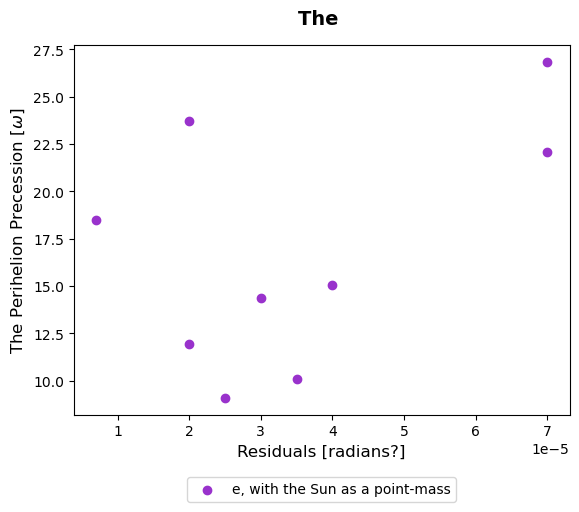

In [8]:
# Create a largest residual list:

residual_list = [3.5*10**(-5), 2.5e-05, 7e-05, 0.7e-05, 7e-05, 4e-05, 3e-05, 2e-05, 2e-05]
formal_err_beta_list = [1.15128940e-05, 5.34587365e-05, 4.00604245e-07, 9.03826870e-06, 5.22910310e-07, 4.72105879e-06, 8.05245961e-06, 2.28045992e-05, 3.75557677e-06]

plt.scatter(residual_list, dw_list, color='darkorchid', label='e, with the Sun as a point-mass')
# plt.plot(epochs_years, e_kep_2, color='turquoise', linestyle=':', label='e, with GR, J2, and Yarkovsky effect')
# plt.plot(epochs_years, e_kep_3, color='teal', label='e, with all 44 celestial bodies considered')
# plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Residuals [radians?]', fontsize=12)
plt.ylabel(f'The Perihelion Precession [$\omega$]', fontsize=12)

# plt.legend()
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.show()

## How to calculate the True Anomaly (with Newton-Raphson)

In [6]:
from math import pi
import numpy as np
from numpy import log as ln

Given e and M, you can also solve for Kepler’s equation:

$$ f(E) = E − e sin(E) − M = 0 $$

where M is the mean anomaly, e is the eccentricity, and E is the eccentric anomaly. Know that e = 0.02 is like the Earth, and e = 0.9 is like a highly eccentric planet.

---
As the eccentric anomaly is to be plotted as a function of the mean anomaly, then define the eccentric anomaly as:

$$ M = E - e sin(E) $$

Additionally note that the mean anomaly is:

$$ M = \frac{2\pi}{T} (t - t_0)$$

And to solve this problem solve for when f(E) = 0.

---

To solve this exercise, do the same as for Q3b, and therefore know that the Newton-Raphson iteration formula is:

$$E_{i + 1} = E_{i} - \frac{f(E_i)}{f'(E_i)} = E_{i} - \frac{E - e \cdot sin(E) - M}{1 - e \cdot cos(E)}$$

In [7]:
def root_finder(E_i_in, M_in, e_in):
    """
    A function which return the eccentric anomaly
    given a mean anomaly and eccentricity
    """
    
    #Define the function
    f_Q3c = lambda E, M, e: E - e*np.sin(E) - M
    
    #Define the derivative
    f_Q3c_der = lambda E, e: 1 - e*np.cos(E)
    
    #Assume we will need less than 100 iterations
    iterations_in = 100
    
    N_array = np.array(range(iterations_in))
    
    for n in N_array:

        #Defining the iteration formula
        E_iplus1_in = E_i_in - (f_Q3c(E_i_in, M_in, e_in))/(f_Q3c_der(E_i_in, e_in))
        #print(E_iplus1_in, E_i_in)

        if abs(E_iplus1_in - E_i_in) < 10**(-15): #It converges to this number very quickly (within 5 itterations)
            #Beware if it doesn't converge quickly, then it may run until 100
            return E_iplus1_in

        E_i_in = E_iplus1_in
        
    return E_iplus1_in

Then once as we've found E, we can now compute $\nu$, the true anomaly:

$ \nu = 2 \cdot arctan(\sqrt{\frac{1+e}{1-e}} tan \frac{E}{2}) $


In [8]:
def nu_function(e_in, E_in):

    nu_out = 2 * np.arctan( np.sqrt((1+e_in)/(1-e_in)) * np.tan(E_in/2))

    return nu_out

In [9]:
eccentric_anomaly_list = []
true_anomaly_list = []

for ast in asteroids:
    i_eq = ast.get_i_eq()

    # The mean anomaly (convert to radians)
    M_rad = np.radians(ast.M)

    # Make an educated guess for E_in
    #I assume it's similar to M (mean anomaly)
    E_ast = root_finder(M_rad, M_rad, ast.e)
    eccentric_anomaly_list.append(E_ast)

    nu_ast = nu_function(ast.e, E_ast)
    true_anomaly_list.append(nu_ast)

print(eccentric_anomaly_list)
print(true_anomaly_list)



[4.939548539638194, 6.175945899165832, 0.2961089285167313, 2.304293601992018, 3.4517711221639193, 2.109478015673329, 3.2225678031126663, 1.8734036118211002, 0.6519265450319258]
[-2.4032012135854846, -0.18146697915286625, 0.6682952683598539, 2.7478161669333074, -3.0680106050189173, 2.5347260893974632, -3.097346647190208, 2.3367349966635618, 1.4705353041856568]


In [10]:
# To make sure the values are correct:

#For TU3 the mean anomaly (M) is 74.76747570797549 (in degrees)
M_TU3 = np.radians(74.76747570797549)

#The eccentricity is unitless (describes how stretchy the surface is)
e_TU3 = 0.4836694929440215

#Make an educated guess
#Additionally, as M and e are single values, E can also be one initial guess
#I assume it's similar to M_TU3
E_value = M_TU3

# Find the eccentric anomaly
E_TU3 = root_finder(E_value, M_TU3, e_TU3)
print(E_TU3)

#The true anomaly:
print(f"{nu_function(e_TU3, E_TU3):.10e}")

1.7782386710231803
2.2486890775e+00


## Determining the Yarkovksy Effect for the 9 asteroids

In [ ]:
# For TU3 the value of A2 is computed 

avg_a_TU3_greenberg = -5.60 * 10**(-4)                       # AU / Myr 
avg_a_TU3_calc = -5.60 * 10**(-4) / (10**6 * 365.25)            # AU / days
uncertain_avg_a_TU3_greenberg = 3.9 * 10**(-4)               # AU / Mry
uncertain_avg_a_TU3_calc = 3.9 * 10**(-4) / (10**6 * 365.25)    # AU / days

# avg_a_greenberg_list = [ -4.84, -560, ]
# Icarus, TU3, 

a_TU3_calc = 0.7875484323220899 # AU
e_TU3_calc = 0.4836694929440215 # unitless
n_TU3_calc = 1.410224212386279  # degrees/ days (remember that angles are unitless in unit conversion)

A_2_TU3_AUdays2 = avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

print(f"The Yarkovksy parameter for TU3: {A_2_TU3_AUdays2} AU / days")
print(A_2_TU3_uncertainty_AUdays2)


The Yarkovksy parameter for TU3: -5.136596706599691e-13 AU / days^2
3.5772727063819274e-13


In [ ]:
# target_mpc_code = [1566, 66146, 66391, 437844, 137924, 138127, 480883, 468468, 364136]
# I could not find 2000 EE14 (the 6th asteroid...)
avg_a_greenberg = np.array([-4.74, -1.60, -5.23, 37.93, -22.10, 0, -48.47, -43.80,  -24.97]) 
avg_a_greenberg_uncertainty = np.array([0.4, 4.5, 2.9, 3.9, 13.5, 0,  2.0, 5.3, 10.3]) 

avg_a_greenberg_r = np.array([-4.84, -5.60, -5.73, 37.42, -26.17, 0, -49.84, -43.81, -38.23]) 
avg_a_greenberg_uncertainty_r = np.array([0.4, 3.9, 2.20, 3.8, 10.4, 0,  0.7, 5.3, 1.8]) 

In [32]:
def Yarkovsky_ms2(avg_a_in, a_in, e_in, n_in):

    """
    A function to calculate the Yarkovksy Parameter.
    The inputs should be <da/dt> in the units of * 10**(-4) AU/Myr, as they appear in Greenberg 2020, 
    semi-axis (a) in AU, eccentricity (unitless), and true anomaly (degrees/day).

    The calculations in this function are described when discussing the Yarkovksy Effect in the Bachelor Thesis.
    """

    # Convert from AU / Myr to * 10**(-4) AU / days
    avg_a_fn_calc = avg_a_in * 10**(-4) / (10**6 * 365.25)

    # The formula takes true anomaly in radians:
    n_rad_in = np.deg2rad(n_in)

    # Calculate the parameter
    A_2_fn_AUdays2 = avg_a_fn_calc * (n_rad_in * (a_in**2) * (1 - (e_in**2))) / 2
    # Convert to m/s2, because Tudat requires this input
    A_2_fn_ms2 = A_2_fn_AUdays2 * 149597870691 / ((24 * 3600)**2)

    return A_2_fn_ms2

# -----------------------------------------------

A_2_values_list = []
i = -1

for ast in asteroids:
    i += 1
    i_eq = ast.get_i_eq()

    # print(
    #     f"{ast.name:<15} | "
    #     f"{ast.a:<8.5f} | "
    #     f"{ast.e:<8.5f} | "
    #     f"{ast.i_ec:<8.5f} | "
    #     f"{ast.node:<10.5f} | "
    #     f"{ast.peri:<10.5f} | "
    #     f"{ast.M:<10.5f} | "
    #     #f"{ast.epoch:<20} | "
    #     f"{i_eq:<10f} |"
    #     f"{ast.n:<10.5f} | "        # testing here
    # )
    A_2_ast_ms2 = Yarkovsky_ms2(avg_a_greenberg_r[i], ast.a, ast.e, ast.n)
    A_2_values_list.append(A_2_ast_ms2)

print(A_2_values_list)
AU_days2_to_m_s2 = (149597870691) / ((24 * 3600)**2)
print(AU_days2_to_m_s2)
A_2_values_AUdays2 = np.array(A_2_values_list) / 20 # * 10**(14)
print(A_2_values_AUdays2)


[-7.4947047935106e-14, -1.79655733799732e-13, -1.1402599897661214e-13, 8.080665194434216e-13, -2.3011625098947506e-13, 0.0, -1.3698663069299618e-12, -1.3118190748109315e-12, -6.383317087378818e-13]
20.040009684043852
[-3.74735240e-15 -8.98278669e-15 -5.70129995e-15  4.04033260e-14
 -1.15058125e-14  0.00000000e+00 -6.84933153e-14 -6.55909537e-14
 -3.19165854e-14]
